In [17]:
import pickle
P = '../cache/models/'
files = {'rung3':'rung3_graphsage_hvg','rung4':'rung4_graphsage_fused','rung5':'rung5_gat_fused'}
for r, f in files.items():
    d = pickle.load(open(P+f+'.pkl','rb'))
    t = d.get('train_time_s')
    print(f'{r}: {t:.1f}s = {t/60:.1f} min' if t is not None else f'{r}: no train_time_s')

rung3: 1708.7s = 28.5 min
rung4: 1916.9s = 31.9 min
rung5: 4347.2s = 72.5 min


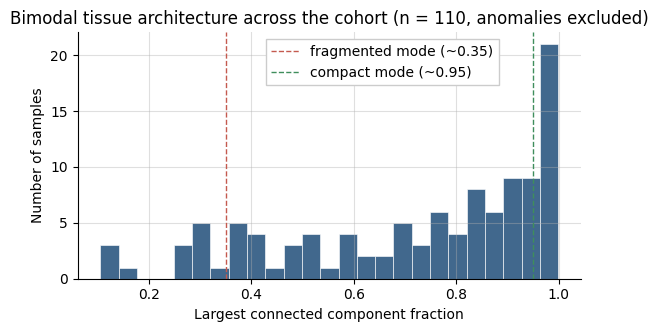

In [14]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Reset & light styling
mpl.rcdefaults()
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.4,
})

# Reload data
ROOT = Path.cwd()
free = pd.read_parquet(ROOT / "../cache" / "topology" / "free_tier.parquet")
clean = free[~free["is_anomaly"]]

PRIMARY = "#1F4E79"
SECONDARY = "#C45A4F"
ACCENT_GREEN = "#3F8E5C"


def plot_bimodality(legend_loc="upper right", framealpha=1.0):
    fig, ax = plt.subplots(figsize=(6.5, 3.2))

    ax.hist(clean["largest_component_frac"], bins=25, color=PRIMARY, alpha=0.85,
            edgecolor="white", linewidth=0.5)

    ax.axvline(0.35, color=SECONDARY, linestyle="--", linewidth=1.0,
               label="fragmented mode (~0.35)")
    ax.axvline(0.95, color=ACCENT_GREEN, linestyle="--", linewidth=1.0,
               label="compact mode (~0.95)")

    ax.set_xlabel("Largest connected component fraction")
    ax.set_ylabel("Number of samples")
    ax.set_title("Bimodal tissue architecture across the cohort (n = 110, anomalies excluded)")

    leg = ax.legend(
        loc="upper right",
        bbox_to_anchor=(0.85, 1.0),
        frameon=True,
        framealpha=framealpha,
        facecolor="white",
        edgecolor="#cccccc",
        fancybox=False,
    )
    leg.set_zorder(10)

    plt.show()
    return fig


fig = plot_bimodality(legend_loc="upper center")

In [15]:
import importlib
import scripts.generate_report_figures
importlib.reload(scripts.generate_report_figures)

from scripts.generate_report_figures import *
set_style()

# Paper bianco: PDF, sfondo bianco, ink scuro
fig_part1_composition_topology_heatmap()

[part1] composition x topology heatmap
  saved report/figures/part1_composition_topology_heatmap.pdf


In [7]:
import sys
sys.path.insert(0, "scripts")
import importlib
import scripts.generate_report_figures
importlib.reload(scripts.generate_report_figures)
from scripts.generate_report_figures import *
set_style()
for i in range(8):
    fig_part4_gene_network_single(class_id=i, font_scale=1.5, chord_edge_color="#5FD0C5",
                                  chord_edge_alpha_boost=1.5, legend_fontsize=12,
                                  bare=True)

[part4] gene network singolo (classe c0)
  loaded ggms_alpha_007_common378.pkl
  loaded bootstraps_alpha_007_common378.pkl
  saved report/figures/transparent/part4_gene_network_full_c0_b_cells.png
  saved report/figures/transparent/part4_gene_network_chord_c0_b_cells.png
[part4] gene network singolo (classe c1)
  loaded ggms_alpha_007_common378.pkl
  loaded bootstraps_alpha_007_common378.pkl
  saved report/figures/transparent/part4_gene_network_full_c1_endothelial.png
  saved report/figures/transparent/part4_gene_network_chord_c1_endothelial.png
[part4] gene network singolo (classe c2)
  loaded ggms_alpha_007_common378.pkl
  loaded bootstraps_alpha_007_common378.pkl
  saved report/figures/transparent/part4_gene_network_full_c2_fibroblasts.png
  saved report/figures/transparent/part4_gene_network_chord_c2_fibroblasts.png
[part4] gene network singolo (classe c3)
  loaded ggms_alpha_007_common378.pkl
  loaded bootstraps_alpha_007_common378.pkl
  saved report/figures/transparent/part4_gene

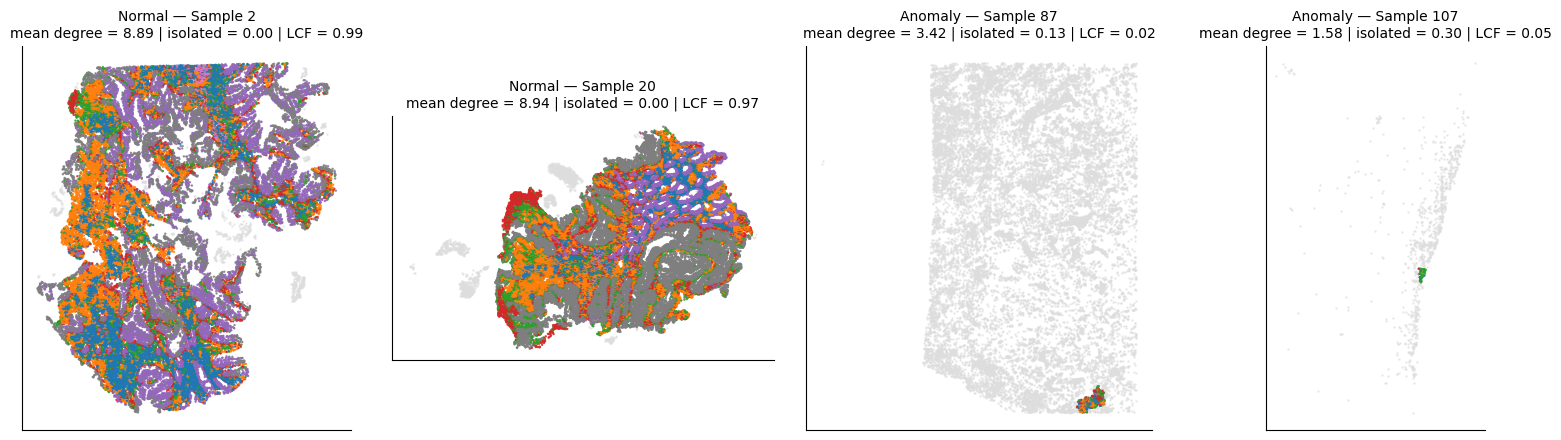

In [16]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import igraph as ig

# Reset matplotlib for notebook display
mpl.rcdefaults()
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import data_io
import graph_construction

# Same 8-color palette used elsewhere
CLASS_COLORS = plt.cm.tab10.colors[:8]

# Reload data
G = data_io.load_global(str(ROOT / "../cache"))
free = pd.read_parquet(ROOT / "../cache" / "topology" / "free_tier.parquet")


def plot_sample_with_giant_component(ax, sample_id, title_prefix=""):
    """One panel: cells colored by cell type if in giant component, gray otherwise."""
    # Build per-sample subgraph
    sg = graph_construction.build_for_sample(sample_id, global_arrays=G, weighted=False)
    pos = G.positions[sg.global_idxs]
    ct = G.cell_type[sg.global_idxs]

    # Find giant connected component using igraph
    src, dst = sg.edge_index
    n_nodes = len(pos)
    g_ig = ig.Graph(n=n_nodes, edges=list(zip(src.tolist(), dst.tolist())), directed=False)
    components = g_ig.connected_components()
    sizes = components.sizes()
    if len(sizes) > 0:
        giant_id = int(np.argmax(sizes))
        membership = np.array(components.membership)
        in_giant = membership == giant_id
    else:
        in_giant = np.zeros(n_nodes, dtype=bool)

    # Plot: non-giant cells first (background, gray), then giant cells (colored)
    not_giant = ~in_giant
    if not_giant.any():
        ax.scatter(pos[not_giant, 0], pos[not_giant, 1],
                   s=0.5, c="#dddddd", alpha=0.6, rasterized=True)
    if in_giant.any():
        ax.scatter(pos[in_giant, 0], pos[in_giant, 1],
                   s=0.5, c=[CLASS_COLORS[c] for c in ct[in_giant]],
                   alpha=0.85, rasterized=True)

    # Stats from free_tier
    row = free.loc[sample_id]
    md = row["mean_degree"]
    fi = row["frac_isolated"]
    lcf = row["largest_component_frac"]

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f"{title_prefix}Sample {sample_id}\n"
        f"mean degree = {md:.2f} | isolated = {fi:.2f} | LCF = {lcf:.2f}",
        fontsize=10
    )
    ax.grid(False)


# 4-panel comparison
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

plot_sample_with_giant_component(axes[0], 2, title_prefix="Normal — ")
plot_sample_with_giant_component(axes[1], 20, title_prefix="Normal — ")
plot_sample_with_giant_component(axes[2], 87, title_prefix="Anomaly — ")
plot_sample_with_giant_component(axes[3], 107, title_prefix="Anomaly — ")

plt.tight_layout()
plt.show()

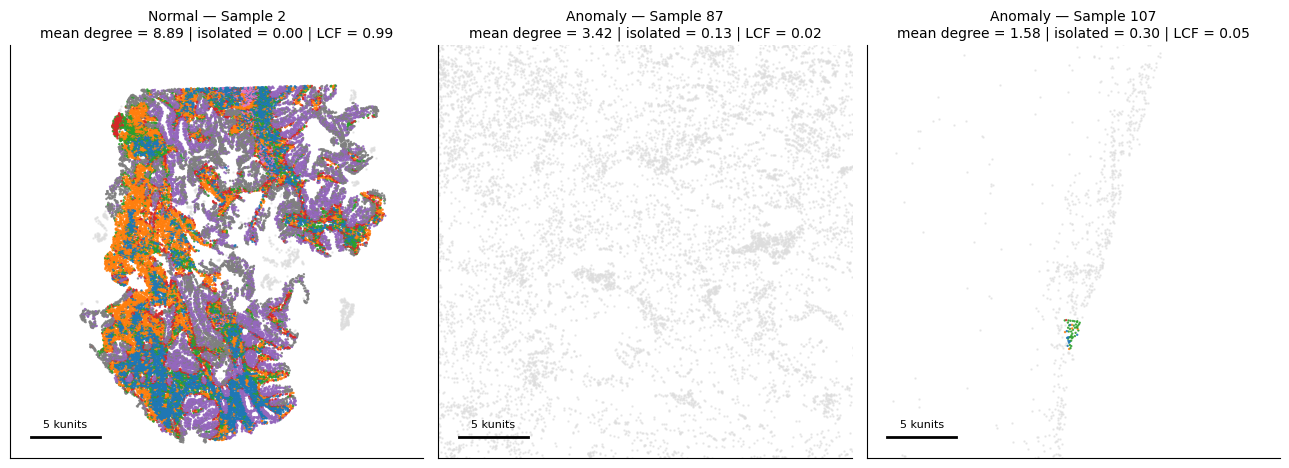

In [18]:
def plot_sample_with_giant_component(ax, sample_id, title_prefix="",
                                       span=30000, draw_scalebar=True):
    """One panel: cells colored by cell type if in giant component, gray otherwise.
    All panels use the same absolute spatial span (default 30000 units), centered
    on the sample centroid, so cell density is visually comparable across panels."""
    # Build per-sample subgraph
    sg = graph_construction.build_for_sample(sample_id, global_arrays=G, weighted=False)
    pos = G.positions[sg.global_idxs]
    ct = G.cell_type[sg.global_idxs]

    # Find giant connected component
    src, dst = sg.edge_index
    n_nodes = len(pos)
    g_ig = ig.Graph(n=n_nodes, edges=list(zip(src.tolist(), dst.tolist())), directed=False)
    components = g_ig.connected_components()
    sizes = components.sizes()
    if len(sizes) > 0:
        giant_id = int(np.argmax(sizes))
        membership = np.array(components.membership)
        in_giant = membership == giant_id
    else:
        in_giant = np.zeros(n_nodes, dtype=bool)

    # Plot: non-giant cells first (background, gray), then giant cells (colored)
    not_giant = ~in_giant
    if not_giant.any():
        ax.scatter(pos[not_giant, 0], pos[not_giant, 1],
                   s=0.5, c="#dddddd", alpha=0.6, rasterized=True)
    if in_giant.any():
        ax.scatter(pos[in_giant, 0], pos[in_giant, 1],
                   s=0.5, c=[CLASS_COLORS[c] for c in ct[in_giant]],
                   alpha=0.85, rasterized=True)

    # === Common spatial scale ===
    # Center on sample centroid, show fixed span
    cx, cy = pos[:, 0].mean(), pos[:, 1].mean()
    half = span / 2
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)

    # === Scalebar (optional) ===
    if draw_scalebar:
        # 5000 units in the bottom-left corner
        bar_length = 5000
        bar_x_start = cx - half + span * 0.05  # 5% from left
        bar_y = cy - half + span * 0.05         # 5% from bottom
        ax.plot([bar_x_start, bar_x_start + bar_length], [bar_y, bar_y],
                "k-", linewidth=2)
        ax.text(bar_x_start + bar_length / 2, bar_y + span * 0.02,
                "5 kunits", ha="center", va="bottom", fontsize=8)

    # Stats from free_tier
    row = free.loc[sample_id]
    md = row["mean_degree"]
    fi = row["frac_isolated"]
    lcf = row["largest_component_frac"]

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(
        f"{title_prefix}Sample {sample_id}\n"
        f"mean degree = {md:.2f} | isolated = {fi:.2f} | LCF = {lcf:.2f}",
        fontsize=10
    )
    ax.grid(False)


# 3-panel comparison: normal + 2 anomalies
fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))

plot_sample_with_giant_component(axes[0], 2, title_prefix="Normal — ")
plot_sample_with_giant_component(axes[1], 87, title_prefix="Anomaly — ")
plot_sample_with_giant_component(axes[2], 107, title_prefix="Anomaly — ")

plt.tight_layout()
plt.show()

In [31]:
import sys
sys.path.insert(0, "scripts")
import importlib
import scripts.generate_report_figures
importlib.reload(scripts.generate_report_figures)
from scripts.generate_report_figures import set_style, fig_part2_niche_recurrence
set_style()
fig_part2_niche_recurrence()

[part2] niche recurrence
  saved report/figures/part2_niche_recurrence.pdf


In [24]:
import sys
sys.path.insert(0, "scripts")
import importlib
import scripts.generate_report_figures
importlib.reload(scripts.generate_report_figures)
from scripts.generate_report_figures import set_style, fig_part2_niche_centroid_heatmap
set_style()
fig_part2_niche_centroid_heatmap()

[part2] niche centroid heatmap
  saved report/figures/part2_niche_centroid_heatmap.pdf


In [35]:
import sys
sys.path.insert(0, "scripts")
import importlib
import scripts.generate_report_figures
importlib.reload(scripts.generate_report_figures)
from scripts.generate_report_figures import *
set_style()
fig_part5_triple_jaccard()
fig_part5_dendrograms()

[part5] triple Jaccard heatmap
  loaded niche_ggms_alpha_007_common378.pkl
  loaded part5_summary.pkl
  saved report/figures/part5_triple_jaccard.pdf
[part5] three dendrograms
  loaded niche_ggms_alpha_007_common378.pkl
  loaded part5_summary.pkl
  saved report/figures/part5_dendrograms.pdf


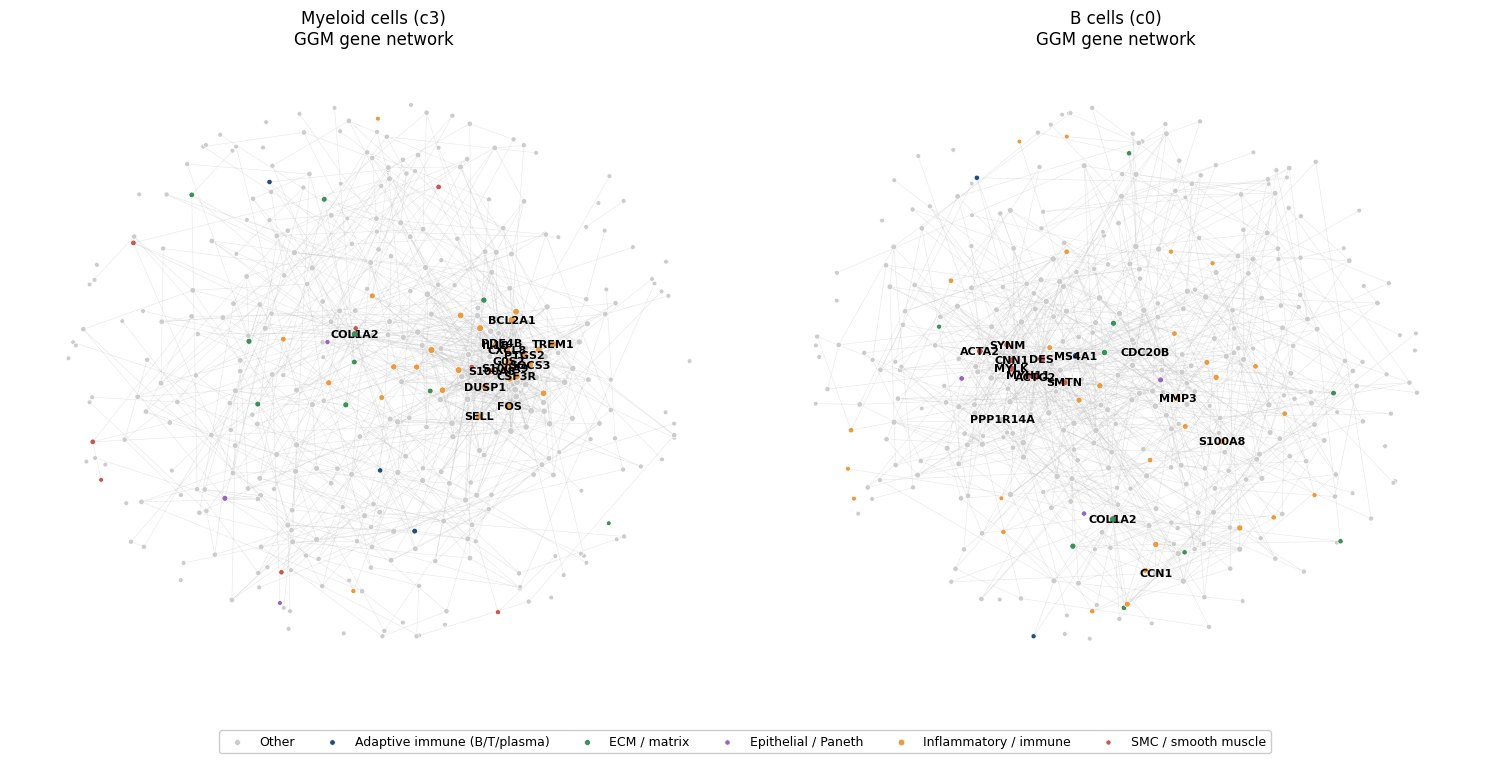

In [2]:
%matplotlib inline
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx

mpl.rcdefaults()
mpl.rcParams.update({
    "figure.facecolor": "white",
})

ROOT = Path.cwd()

# Load GGM artifacts
with open(ROOT / "../cache" / "ggm" / "ggms_alpha_007_common378.pkl", "rb") as f:
    ggms = pickle.load(f)
gene_names = pd.read_csv("../data/gene_names.csv")["0"].values
common_idx = ggms["common_gene_global"]
common_symbols = gene_names[common_idx]


# Biological family mapping
FAMILY_GROUPS = {
    "SMC / smooth muscle": ["DES", "ACTG2", "MYH11", "ACTA2", "MYLK", "CNN1",
                              "SMTN", "SYNM", "TAGLN"],
    "Inflammatory / immune": ["CXCL8", "CXCL5", "S100A8", "S100A9", "IL1B",
                               "IL1RN", "PTGS2", "G0S2", "CSF3R", "BCL2A1",
                               "FOS", "FOSB", "DUSP1", "SOCS3", "TREM1", "SELL",
                               "EGR1", "CXCR2", "FCAR", "MT2A", "CCL3", "CCL5",
                               "MMP1", "MMP3", "MMP12", "MMP25", "PLEK", "ITGAX",
                               "SCG2", "SIGLEC5"],
    "ECM / matrix": ["COL1A2", "COL7A1", "TIMP3", "ELN", "SFRP4", "SFRP2",
                       "MGP", "MFAP4", "TNXB", "IGFBP5"],
    "Epithelial / Paneth": ["SLC26A3", "FXYD6", "DEFA6", "ALPI", "EPCAM", "KRT8"],
    "Adaptive immune (B/T/plasma)": ["MS4A1", "IGHM", "IGLC1", "CD79A", "CD79B"],
}
FAMILY_COLORS = {
    "SMC / smooth muscle":           "#C45A4F",     # red
    "Inflammatory / immune":          "#E89B3F",     # orange
    "ECM / matrix":                   "#3F8E5C",     # green
    "Epithelial / Paneth":            "#9467BD",     # purple
    "Adaptive immune (B/T/plasma)":   "#1F4E79",     # dark blue
    "Other":                           "#cccccc",     # light gray
}

# Build symbol -> family lookup
SYMBOL_TO_FAMILY = {}
for fam, syms in FAMILY_GROUPS.items():
    for s in syms:
        SYMBOL_TO_FAMILY[s] = fam


def gene_family(symbol):
    return SYMBOL_TO_FAMILY.get(symbol, "Other")


def build_gene_network_for_class(class_id):
    """Return a networkx Graph for a given cell-type class."""
    data = ggms["per_class"][class_id]
    precision = data["precision_"]
    n = precision.shape[0]

    G = nx.Graph()
    for i in range(n):
        G.add_node(i, symbol=common_symbols[i],
                   family=gene_family(common_symbols[i]),
                   degree=int(data["degree"][i]))

    # Add edges (off-diagonal non-zeros of precision matrix)
    for i in range(n):
        for j in range(i + 1, n):
            if abs(precision[i, j]) > 0:
                G.add_edge(i, j, weight=abs(precision[i, j]))

    return G


def plot_network(ax, G, title, top_n_labels=15, seed=42):
    """Draw a graph on `ax` with biological coloring."""
    # Position using spring layout
    pos = nx.spring_layout(G, seed=seed, k=0.15, iterations=80)

    # Edges (drawn first, light gray)
    edges = list(G.edges())
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                            edge_color="#bbbbbb", alpha=0.35, width=0.4)

    # Nodes grouped by family for legend
    degrees = np.array([G.nodes[n]["degree"] for n in G.nodes()])
    node_sizes = 8 + 4 * np.sqrt(np.maximum(degrees, 1))  # area ∝ sqrt(degree)

    # Plot each family separately for legend handles
    families_present = sorted(set(G.nodes[n]["family"] for n in G.nodes()))
    # Push "Other" to first (drawn behind everything)
    if "Other" in families_present:
        families_present.remove("Other")
        families_present = ["Other"] + families_present

    for fam in families_present:
        nodes_in_fam = [n for n in G.nodes() if G.nodes[n]["family"] == fam]
        sizes_in_fam = [node_sizes[i] for i, n in enumerate(G.nodes())
                         if G.nodes[n]["family"] == fam]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes_in_fam,
                                node_size=sizes_in_fam,
                                node_color=FAMILY_COLORS[fam],
                                edgecolors="white", linewidths=0.5,
                                label=fam)

    # Labels for top-N hubs
    nodes_sorted_by_degree = sorted(G.nodes(), key=lambda n: -G.nodes[n]["degree"])
    top_hubs = nodes_sorted_by_degree[:top_n_labels]
    labels = {n: G.nodes[n]["symbol"] for n in top_hubs}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8,
                             font_weight="bold")

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))

G_myeloid = build_gene_network_for_class(3)
G_bcell = build_gene_network_for_class(0)

plot_network(axes[0], G_myeloid, "Myeloid cells (c3)\nGGM gene network", top_n_labels=15)
plot_network(axes[1], G_bcell, "B cells (c0)\nGGM gene network", top_n_labels=15)

# Common legend at the bottom
handles, labels = axes[0].get_legend_handles_labels()
# Deduplicate
seen = set()
unique = []
for h, l in zip(handles, labels):
    if l not in seen:
        seen.add(l)
        unique.append((h, l))
fig.legend(*zip(*unique), loc="lower center", ncol=6, frameon=True,
           framealpha=1.0, facecolor="white", edgecolor="#cccccc",
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

/tmp/ipykernel_42378/320692101.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.98])


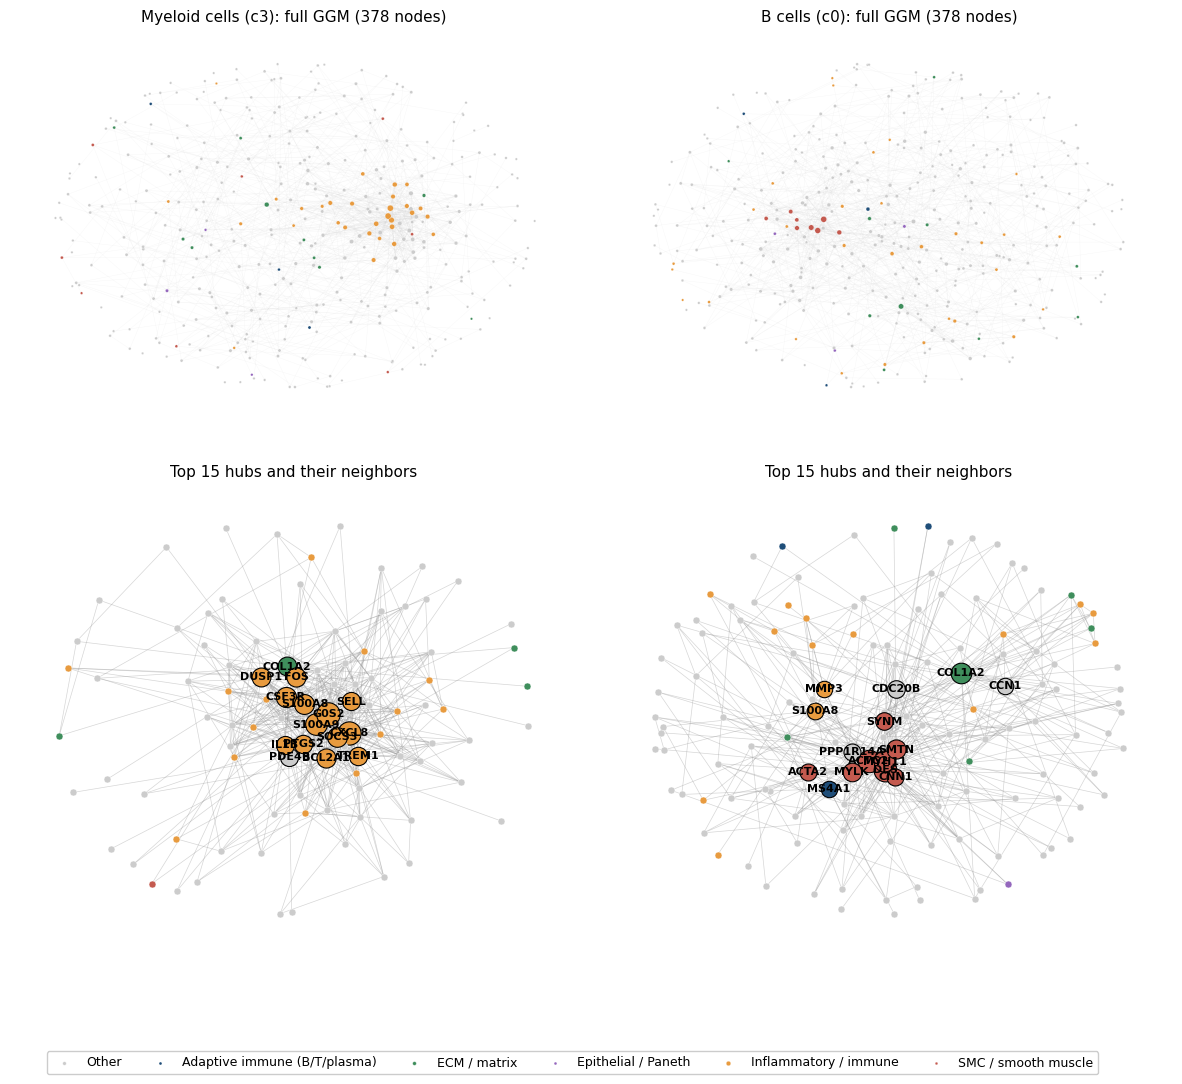

In [3]:
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx

mpl.rcdefaults()
mpl.rcParams.update({"figure.facecolor": "white"})

ROOT = Path.cwd()

# Reload everything (in case kernel was reset)
with open(ROOT / "../cache" / "ggm" / "ggms_alpha_007_common378.pkl", "rb") as f:
    ggms = pickle.load(f)
gene_names = pd.read_csv("../data/gene_names.csv")["0"].values
common_idx = ggms["common_gene_global"]
common_symbols = gene_names[common_idx]

FAMILY_GROUPS = {
    "SMC / smooth muscle": ["DES", "ACTG2", "MYH11", "ACTA2", "MYLK", "CNN1",
                              "SMTN", "SYNM", "TAGLN"],
    "Inflammatory / immune": ["CXCL8", "CXCL5", "S100A8", "S100A9", "IL1B",
                               "IL1RN", "PTGS2", "G0S2", "CSF3R", "BCL2A1",
                               "FOS", "FOSB", "DUSP1", "SOCS3", "TREM1", "SELL",
                               "EGR1", "CXCR2", "FCAR", "MT2A", "CCL3", "CCL5",
                               "MMP1", "MMP3", "MMP12", "MMP25", "PLEK", "ITGAX",
                               "SCG2", "SIGLEC5"],
    "ECM / matrix": ["COL1A2", "COL7A1", "TIMP3", "ELN", "SFRP4", "SFRP2",
                       "MGP", "MFAP4", "TNXB", "IGFBP5"],
    "Epithelial / Paneth": ["SLC26A3", "FXYD6", "DEFA6", "ALPI", "EPCAM", "KRT8"],
    "Adaptive immune (B/T/plasma)": ["MS4A1", "IGHM", "IGLC1", "CD79A", "CD79B"],
}
FAMILY_COLORS = {
    "SMC / smooth muscle":            "#C45A4F",
    "Inflammatory / immune":           "#E89B3F",
    "ECM / matrix":                    "#3F8E5C",
    "Epithelial / Paneth":             "#9467BD",
    "Adaptive immune (B/T/plasma)":    "#1F4E79",
    "Other":                            "#cccccc",
}

SYMBOL_TO_FAMILY = {}
for fam, syms in FAMILY_GROUPS.items():
    for s in syms:
        SYMBOL_TO_FAMILY[s] = fam


def gene_family(symbol):
    return SYMBOL_TO_FAMILY.get(symbol, "Other")


def build_gene_network_for_class(class_id):
    data = ggms["per_class"][class_id]
    precision = data["precision_"]
    n = precision.shape[0]
    G = nx.Graph()
    for i in range(n):
        G.add_node(i, symbol=common_symbols[i],
                   family=gene_family(common_symbols[i]),
                   degree=int(data["degree"][i]))
    for i in range(n):
        for j in range(i + 1, n):
            if abs(precision[i, j]) > 0:
                G.add_edge(i, j, weight=abs(precision[i, j]))
    return G


def subnetwork_top_hubs_plus_neighbors(G_full, top_n=15):
    """Extract the top-n hubs and their direct neighbors as a subgraph."""
    nodes_sorted = sorted(G_full.nodes(), key=lambda n: -G_full.nodes[n]["degree"])
    top_hubs = set(nodes_sorted[:top_n])
    neighbors = set()
    for h in top_hubs:
        neighbors.update(G_full.neighbors(h))
    keep = top_hubs | neighbors
    return G_full.subgraph(keep).copy(), top_hubs


def plot_full_network_panel(ax, G, title, seed=42):
    """Big-picture panel: all 378 nodes, very faint edges, small nodes."""
    pos = nx.spring_layout(G, seed=seed, k=0.18, iterations=80)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#cccccc",
                            alpha=0.18, width=0.25)
    families_present = sorted(set(G.nodes[n]["family"] for n in G.nodes()))
    if "Other" in families_present:
        families_present.remove("Other")
        families_present = ["Other"] + families_present
    for fam in families_present:
        nodes_in_fam = [n for n in G.nodes() if G.nodes[n]["family"] == fam]
        sizes = [3 + G.nodes[n]["degree"] * 0.4 for n in nodes_in_fam]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes_in_fam,
                                node_size=sizes,
                                node_color=FAMILY_COLORS[fam],
                                edgecolors="white", linewidths=0.2,
                                label=fam)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")
    return pos


def plot_hub_inset(ax, G_full, seed=42, top_n=15):
    """Inset zoom on top-n hubs + neighbors, with labels."""
    G_sub, top_hubs = subnetwork_top_hubs_plus_neighbors(G_full, top_n=top_n)
    pos = nx.spring_layout(G_sub, seed=seed, k=0.4, iterations=100)
    nx.draw_networkx_edges(G_sub, pos, ax=ax, edge_color="#999999",
                            alpha=0.4, width=0.5)
    for n_id in G_sub.nodes():
        fam = G_sub.nodes[n_id]["family"]
        deg = G_sub.nodes[n_id]["degree"]
        is_hub = n_id in top_hubs
        size = 80 + 5 * deg if is_hub else 25
        ax.scatter([pos[n_id][0]], [pos[n_id][1]],
                   s=size, c=FAMILY_COLORS[fam],
                   edgecolors="black" if is_hub else "white",
                   linewidths=0.8 if is_hub else 0.3,
                   zorder=2)
    labels = {n: G_sub.nodes[n]["symbol"] for n in top_hubs}
    nx.draw_networkx_labels(G_sub, pos, labels=labels, ax=ax,
                             font_size=8, font_weight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")


# Build networks
G_myeloid = build_gene_network_for_class(3)
G_bcell = build_gene_network_for_class(0)

# Create 2x2 figure: top row = full networks, bottom row = hub insets
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.2], hspace=0.15, wspace=0.05)

ax_full_m = fig.add_subplot(gs[0, 0])
ax_full_b = fig.add_subplot(gs[0, 1])
ax_inset_m = fig.add_subplot(gs[1, 0])
ax_inset_b = fig.add_subplot(gs[1, 1])

plot_full_network_panel(ax_full_m, G_myeloid,
                          "Myeloid cells (c3): full GGM (378 nodes)")
plot_full_network_panel(ax_full_b, G_bcell,
                          "B cells (c0): full GGM (378 nodes)")

plot_hub_inset(ax_inset_m, G_myeloid)
plot_hub_inset(ax_inset_b, G_bcell)
ax_inset_m.set_title("Top 15 hubs and their neighbors", fontsize=11)
ax_inset_b.set_title("Top 15 hubs and their neighbors", fontsize=11)

# Common legend
handles, labels = ax_full_m.get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
fig.legend(*zip(*unique), loc="lower center", ncol=6, frameon=True,
           framealpha=1.0, facecolor="white", edgecolor="#cccccc",
           fontsize=9, bbox_to_anchor=(0.5, 0.005))

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

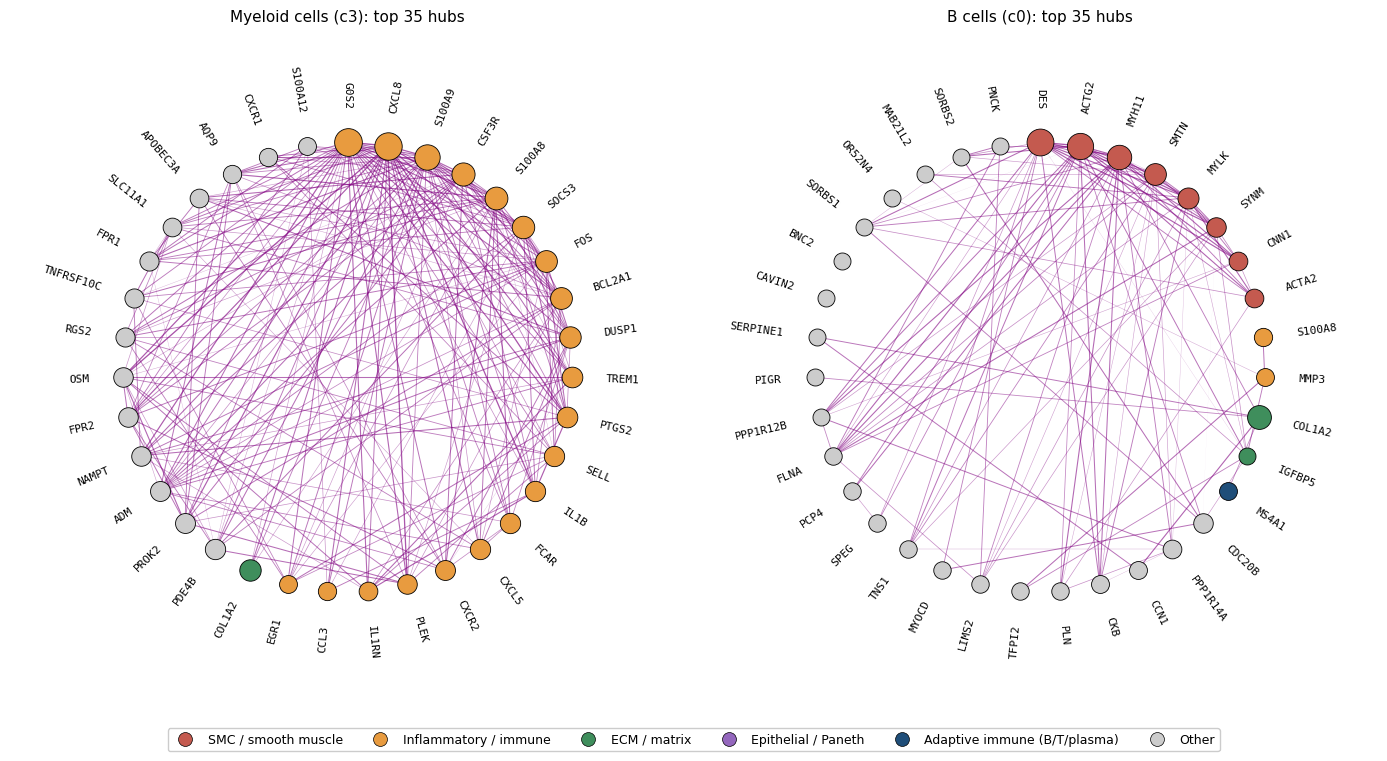

In [24]:
def plot_chord_for_class(ax, G_full, ggm_data, title, top_n=35):
    """
    Circular layout of top-n hubs. Edge thickness is log-scaled by |precision|.
    """
    nodes_sorted = sorted(G_full.nodes(), key=lambda n: -G_full.nodes[n]["degree"])
    top_hubs = nodes_sorted[:top_n]
    G_sub = G_full.subgraph(top_hubs).copy()

    family_order = [
        "SMC / smooth muscle",
        "Inflammatory / immune",
        "ECM / matrix",
        "Adaptive immune (B/T/plasma)",
        "Epithelial / Paneth",
        "Other",
    ]
    def family_sort_key(n):
        fam = G_sub.nodes[n]["family"]
        fam_idx = family_order.index(fam) if fam in family_order else 999
        return (fam_idx, -G_sub.nodes[n]["degree"])
    sorted_hubs = sorted(G_sub.nodes(), key=family_sort_key)

    n_nodes = len(sorted_hubs)
    angles = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi, n_nodes, endpoint=False)
    pos = {n: (np.cos(a), np.sin(a)) for n, a in zip(sorted_hubs, angles)}

    # === Edges with log-scaled thickness ===
    precision = ggm_data["precision_"]
    edge_data = []
    for u, v in G_sub.edges():
        w = abs(precision[u, v])
        edge_data.append((u, v, w))

    if edge_data:
        log_weights = np.log10([w for _, _, w in edge_data])
        lw_min, lw_max = 0.2, 3.0   # min/max linewidth
        # Normalize log_weights to [0, 1]
        lw_lo, lw_hi = log_weights.min(), log_weights.max()
        if lw_hi > lw_lo:
            normed = (log_weights - lw_lo) / (lw_hi - lw_lo)
        else:
            normed = np.zeros_like(log_weights)
        # Map to linewidth range
        linewidths = normed#lw_min + (lw_max - lw_min) * normed
        # Also map to alpha for visual hierarchy
        alphas = 0.15 + 0.55 * normed

        for (u, v, w), lw, al in zip(edge_data, linewidths, alphas):
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            ax.plot([x0, x1], [y0, y1], color="purple", alpha=al,
                    linewidth=lw, zorder=1)

    # Nodes
    for n_id in sorted_hubs:
        fam = G_sub.nodes[n_id]["family"]
        deg = G_sub.nodes[n_id]["degree"]
        ax.scatter([pos[n_id][0]], [pos[n_id][1]], s=70 + 8 * deg,
                   c=FAMILY_COLORS[fam], edgecolors="black", linewidths=0.6,
                   zorder=3)

    # Labels
    for n_id, angle in zip(sorted_hubs, angles):
        symbol = G_sub.nodes[n_id]["symbol"]
        x = 1.15 * np.cos(angle)
        y = 1.15 * np.sin(angle)
        rot_deg = np.degrees(angle)
        if -90 < rot_deg < 90:
            ha = "left"
        else:
            ha = "right"
            rot_deg += 180
        ax.text(x, y, symbol, ha=ha, va="center", fontsize=8,
                rotation=rot_deg, rotation_mode="anchor",
                family="monospace")

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")
    ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
plot_chord_for_class(axes[0], G_myeloid, ggms["per_class"][3],
                       "Myeloid cells (c3): top 35 hubs", top_n=35)
plot_chord_for_class(axes[1], G_bcell, ggms["per_class"][0],
                       "B cells (c0): top 35 hubs", top_n=35)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=fam,
           markerfacecolor=col, markeredgecolor="black",
           markeredgewidth=0.5, markersize=10)
    for fam, col in FAMILY_COLORS.items()
]
fig.legend(handles=legend_handles, loc="lower center", ncol=6,
           frameon=True, framealpha=1.0, facecolor="white",
           edgecolor="#cccccc", fontsize=9, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

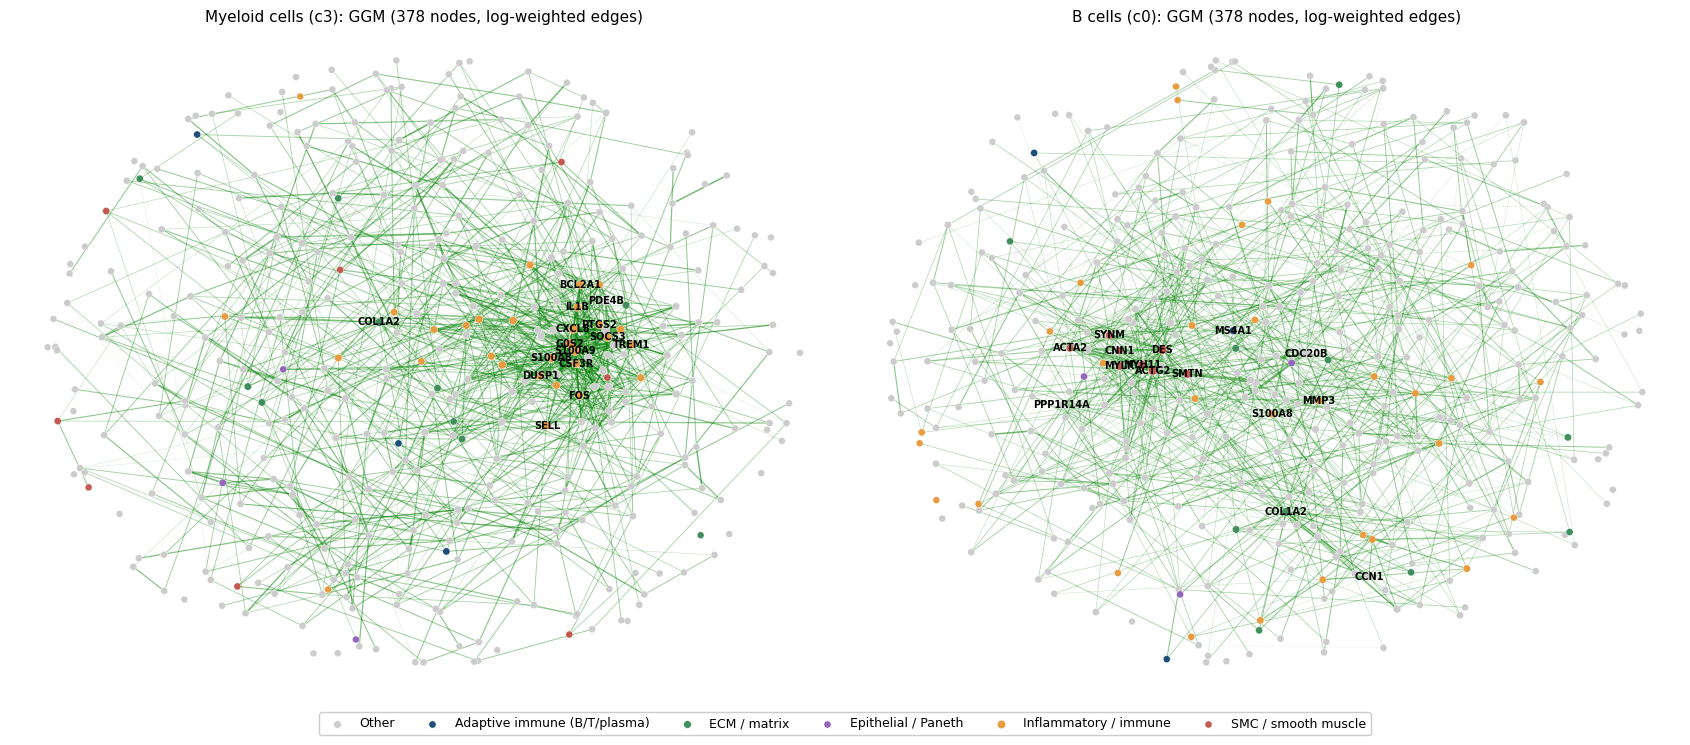

In [33]:
def plot_full_network_weighted(ax, G, ggm_data, title, seed=42, top_n_labels=15):
    """
    Full network of all 378 nodes with edge thickness log-scaled by |precision|.
    Top-N hubs get labels.
    """
    pos = nx.spring_layout(G, seed=seed, k=0.18, iterations=80)

    # === Edges with log-scaled thickness ===
    precision = ggm_data["precision_"]
    edge_data = []
    for u, v in G.edges():
        w = abs(precision[u, v])
        edge_data.append((u, v, w))

    if edge_data:
        log_weights = np.log10([w for _, _, w in edge_data])
        lw_lo, lw_hi = log_weights.min(), log_weights.max()
        if lw_hi > lw_lo:
            normed = (log_weights - lw_lo) / (lw_hi - lw_lo)
        else:
            normed = np.zeros_like(log_weights)

        # Linewidth: weak edges almost invisible, strong edges noticeable
        linewidths = 0.01 + 1.1 * normed
        # Alpha: weak edges very transparent, strong edges visible
        alphas = 0.05 + 0.50 * normed

        for (u, v, w), lw, al in zip(edge_data, linewidths, alphas):
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            ax.plot([x0, x1], [y0, y1], color="green", alpha=al,
                    linewidth=lw, zorder=1)

    # Nodes grouped by family for legend
    families_present = sorted(set(G.nodes[n]["family"] for n in G.nodes()))
    if "Other" in families_present:
        families_present.remove("Other")
        families_present = ["Other"] + families_present

    for fam in families_present:
        nodes_in_fam = [n for n in G.nodes() if G.nodes[n]["family"] == fam]
        sizes_in_fam = [25 + G.nodes[n]["degree"] * 0.5 for n in nodes_in_fam]
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes_in_fam,
                                node_size=sizes_in_fam,
                                node_color=FAMILY_COLORS[fam],
                                edgecolors="white", linewidths=0.3,
                                label=fam)

    # Labels only for top-N hubs
    nodes_sorted = sorted(G.nodes(), key=lambda n: -G.nodes[n]["degree"])
    top_hubs = nodes_sorted[:top_n_labels]
    labels = {n: G.nodes[n]["symbol"] for n in top_hubs}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=7,
                             font_weight="bold", font_color="black")

    ax.set_title(title, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
plot_full_network_weighted(axes[0], G_myeloid, ggms["per_class"][3],
                              "Myeloid cells (c3): GGM (378 nodes, log-weighted edges)",
                              top_n_labels=15)
plot_full_network_weighted(axes[1], G_bcell, ggms["per_class"][0],
                              "B cells (c0): GGM (378 nodes, log-weighted edges)",
                              top_n_labels=15)

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
seen = set()
unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
fig.legend(*zip(*unique), loc="lower center", ncol=6, frameon=True,
           framealpha=1.0, facecolor="white", edgecolor="#cccccc",
           fontsize=9, bbox_to_anchor=(0.5, 0.005))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from sklearn.neighbors import NearestNeighbors

ROOT = Path.cwd()
CACHE = (ROOT / "../cache").resolve()
CLASS_COLORS = plt.cm.tab10.colors[:8]
from scripts.generate_report_figures import save

ROSE, PLUM, T_CLASS = "#C73E6B", "#2A1B33", 6     # rose = T-cell accent; plum = bg


def fig_title_hero(sample_id=47, seed=1,
                   band1=(0.18, 0.42), band2=(0.55, 0.74),
                   n_graph=1500, k=8, he_path=None):
    """
    Title hero: a registered tissue region dissolving left -> right,
    from real H&E -> segmented cells -> spatial KNN graph.
    band1 = H&E->cells crossfade, band2 = cells->graph crossfade
    (fractions of the region width). T cells are drawn in rose.
    """
    import data_io
    import graph_construction

    # --- load sample + build its spatial graph ---
    G   = data_io.load_global(str(CACHE))
    sg  = graph_construction.build_for_sample(sample_id, global_arrays=G, weighted=False)
    pos = G.positions[sg.global_idxs]
    ct  = G.cell_type[sg.global_idxs]

    # --- pick a dense, representative square region ---
    xmin, xmax = pos[:, 0].min(), pos[:, 0].max()
    ymin, ymax = pos[:, 1].min(), pos[:, 1].max()
    rw, rh = (xmax - xmin) * 0.22, (ymax - ymin) * 0.22
    rng = np.random.default_rng(seed)
    best = (-1, None)
    for _ in range(80):
        cxx = rng.uniform(xmin + rw / 2, xmax - rw / 2)
        cyy = rng.uniform(ymin + rh / 2, ymax - rh / 2)
        m = (np.abs(pos[:, 0] - cxx) < rw / 2) & (np.abs(pos[:, 1] - cyy) < rh / 2)
        if m.sum() > best[0]:
            best = (int(m.sum()), (cxx, cyy))
    cx, cy = best[1]
    region = (np.abs(pos[:, 0] - cx) < rw / 2) & (np.abs(pos[:, 1] - cy) < rh / 2)
    rpos, rct = pos[region], ct[region]
    nx = (rpos[:, 0] - (cx - rw / 2)) / rw                     # normalized x drives the crossfade
    print(f"  region: {region.sum():,} cells at centre ({cx:.0f}, {cy:.0f})")

    # --- subsample -> readable graph nodes, rebuild a clean KNN ---
    rng2 = np.random.default_rng(seed + 100)
    sub  = rng2.choice(len(rpos), size=min(n_graph, len(rpos)), replace=False)
    gpos, gct, gnx = rpos[sub], rct[sub], nx[sub]
    nn = NearestNeighbors(n_neighbors=k + 1).fit(gpos)
    _, idx = nn.kneighbors(gpos)
    ei = np.repeat(np.arange(len(sub)), k)
    ej = idx[:, 1:].reshape(-1)
    und = ei < ej
    ei, ej = ei[und], ej[und]

    # --- smoothstep crossfade helpers ---
    def ramp_up(x, b):   t = np.clip((x - b[0]) / (b[1] - b[0]), 0, 1); return t * t * (3 - 2 * t)
    def ramp_down(x, b): t = np.clip((b[1] - x) / (b[1] - b[0]), 0, 1); return t * t * (3 - 2 * t)

    base = [mcolors.to_rgb(c) for c in CLASS_COLORS]

    # --- per-element opacity (3 stages) ---
    a_node   = ramp_up(gnx, band2)
    a_edge   = ramp_up((gnx[ei] + gnx[ej]) / 2, band2)
    a_tissue = ramp_up(nx, band1) * ramp_down(nx, band2)       # cell field = plateau

    # --- colours (T cells -> rose) ---
    node_rgb  = np.array([mcolors.to_rgb(ROSE) if c == T_CLASS else base[c] for c in gct])
    node_rgba = np.concatenate([node_rgb, a_node[:, None]], axis=1)
    ring_rgba = np.zeros((len(gct), 4)); ring_rgba[:, :3] = 1.0
    ring_rgba[:, 3] = np.clip((a_node - 0.45) / 0.45, 0.0, 1.0)

    tis_rgb  = np.array([mcolors.to_rgb(ROSE) if c == T_CLASS else base[c] for c in rct])
    tis_rgba = np.concatenate([tis_rgb, (a_tissue * 0.6)[:, None]], axis=1)

    segs = np.stack([gpos[ei], gpos[ej]], axis=1)
    edge_rgba = np.zeros((len(ei), 4)); edge_rgba[:, :3] = mcolors.to_rgb("#888888")
    edge_rgba[:, 3] = a_edge * 0.6

    # --- figure ---
    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor(PLUM); ax.set_facecolor(PLUM)

    # (0) registered H&E, fading out across band1; white background hidden (no veil)
    if he_path is not None:
        he = plt.imread(he_path)
        alpha = np.tile(ramp_down(np.linspace(0.0, 1.0, he.shape[1]), band1), (he.shape[0], 1))
        alpha *= (he[..., :3].mean(2) < 0.85)
        ax.imshow(he, extent=[cx - rw / 2, cx + rw / 2, cy - rh / 2, cy + rh / 2],
                  origin="upper", alpha=alpha, zorder=0, aspect="auto")

    # (1) cell field   (2) graph edges   (3) graph nodes
    ax.scatter(rpos[:, 0], rpos[:, 1], s=4, facecolors=tis_rgba,
               edgecolors="none", zorder=1, rasterized=True)
    ax.add_collection(LineCollection(segs, colors=edge_rgba, linewidths=0.6, zorder=2))
    ax.scatter(gpos[:, 0], gpos[:, 1], s=10, facecolors=node_rgba,
               edgecolors=ring_rgba, linewidths=0.6, zorder=3)

    ax.set_xlim(cx - rw / 2, cx + rw / 2); ax.set_ylim(cy - rh / 2, cy + rh / 2)
    ax.set_aspect("equal"); ax.axis("off")
    save(fig, "title_hero", png=True, dpi=300, transparent=True)


fig_title_hero(he_path="he_region.png")

  region: 9,529 cells at centre (34700, 22104)
  saved report/figures/title_hero.png


In [4]:
import zarr, numpy as np
from PIL import Image

DATA = "/group/sottoriva/00-LAB/IMAGES_SCANS/MINERVA/public"
name = "U03_011_B1_S1_T2"

g = zarr.open_group(f"{DATA}/he_images_omezarr/{name}.ome.zarr", mode="r")["0"]
lvl = min(g.array_keys(), key=lambda k: abs(g[k].shape[-1] - 6000))   # più risoluzione = zoom nitido
img = np.asarray(g[lvl][0, :, 0, :, :]).transpose(1, 2, 0)
gray = img.mean(2)
H, W = gray.shape

# finestra ZOOMATA piccola, rapporto ~1:2.4 (alta), da riempire tutta di tessuto
winH = int(H * 0.42)
winW = int(winH / 2.4)
step = max(8, winW // 6)

best = (-1.0, 0, 0)
for y0 in range(0, H - winH + 1, step):
    for x0 in range(0, W - winW + 1, step):
        frac = (gray[y0:y0+winH, x0:x0+winW] < 210).mean()   # tessuto = non bianco
        if frac > best[0]:
            best = (frac, y0, x0)
frac, y0, x0 = best
print(f"livello {lvl} | finestra densa a x={x0}, y={y0} | densità tessuto = {frac:.3f}")

strip = img[y0:y0+winH, x0:x0+winW]
Image.fromarray(strip).save("he_texture.png")
print("salvato:", strip.shape)

/home/matteo.doria/Desktop/ASLCD/.venv/lib/python3.12/site-packages/zarr/core/group.py:3559: ZarrUserWarning: Object at .DS_Store is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


livello 4 | finestra densa a x=2310, y=2618 | densità tessuto = 0.885
salvato: (2226, 927, 3)


In [10]:
import zarr, numpy as np, matplotlib.pyplot as plt

PROJ = "/home/matteo.doria/Desktop/ASLCD"
DATA = "/group/sottoriva/00-LAB/IMAGES_SCANS/MINERVA/public"
name = "U03_011_B1_S1_T2"
sample_id, seed, FLIP = 47, 1, True       # FLIP = il tuo flip verticale

# --- ricostruisci ESATTAMENTE la regione dell'hero (stesso seed) ---
samp = np.load(f"{PROJ}/cache/global/sample.npy")
pos  = np.load(f"{PROJ}/cache/global/positions.npy")
p = pos[samp == sample_id]
xmin,xmax,ymin,ymax = p[:,0].min(),p[:,0].max(),p[:,1].min(),p[:,1].max()
rng = np.random.default_rng(seed)
rw, rh = (xmax-xmin)*0.22, (ymax-ymin)*0.22
best=(-1,None)
for _ in range(80):
    a_=rng.uniform(xmin+rw/2,xmax-rw/2); b_=rng.uniform(ymin+rh/2,ymax-rh/2)
    mm=(np.abs(p[:,0]-a_)<rw/2)&(np.abs(p[:,1]-b_)<rh/2)
    if mm.sum()>best[0]: best=(int(mm.sum()),(a_,b_))
cx,cy = best[1]
x0,x1,y0,y1 = cx-rw/2, cx+rw/2, cy-rh/2, cy+rh/2
rp = p[(np.abs(p[:,0]-cx)<rw/2)&(np.abs(p[:,1]-cy)<rh/2)]
print(f"regione: centro ({cx:.0f},{cy:.0f}) bbox x[{x0:.0f},{x1:.0f}] y[{y0:.0f},{y1:.0f}]")

# --- ritaglia l'H&E sullo STESSO bbox (assume positions == pixel livello 0) ---
g = zarr.open_group(f"{DATA}/he_images_omezarr/{name}.ome.zarr", mode="r")["0"]
L0Y, L0X = g["0"].shape[-2], g["0"].shape[-1]
print("U03_011 L0 (Y,X):", L0Y, L0X, "| la regione ci sta:", (x1<=L0X and y1<=L0Y))
level = 2; f = 2**level
crop = np.asarray(g[str(level)][0,:,0, int(y0/f):int(y1/f), int(x0/f):int(x1/f)]).transpose(1,2,0)
print("crop:", crop.shape, "| densità tessuto:", round((crop.mean(2)<210).mean(),3))

# --- verifica: H&E + cellule sovrapposte ---
disp = np.flipud(crop) if FLIP else crop
fig, ax = plt.subplots(figsize=(7,8))
ax.imshow(disp, extent=[x0,x1,y0,y1], origin="upper", aspect="auto")
ax.scatter(rp[:,0], rp[:,1], s=2, c="lime", alpha=0.35)
ax.set_xlim(x0,x1); ax.set_ylim(y0,y1)
ax.set_title("H&E ritagliata (flip) + cellule — SI ALLINEANO?")
plt.savefig("he_register_check.png", dpi=120, bbox_inches="tight"); plt.close()
print("salvato he_register_check.png")

regione: centro (34700,22104) bbox x[28657,40743] y[15416,28791]
U03_011 L0 (Y,X): 84847 86560 | la regione ci sta: True
crop: (3343, 3021, 3) | densità tessuto: 0.783
salvato he_register_check.png


In [11]:
from PIL import Image
Image.fromarray(disp).save("he_region.png")
print("salvato he_region.png", disp.shape)

salvato he_region.png (3343, 3021, 3)
